# Démonstration d'inférence U-TILISE

Ce notebook montre comment charger un modèle entraîné et produire des reconstructions
sans nuages sur un échantillon du jeu de test.

**Contenu :**
1. Configuration et variables d'environnement
2. Préparation du jeu de test
3. Chargement du modèle depuis un checkpoint
4. Chargement d'un échantillon de test
5. Inférence et visualisation des résultats
6. Visualisation des masques d'attention
7. Calcul des métriques de reconstruction

> **Prérequis :** l'environnement conda `cloud_reconstruction` doit être activé.
> Un checkpoint entraîné et le fichier HDF5 doivent être accessibles.

In [ ]:
import os
import sys
import matplotlib.pyplot as plt
import numpy as np

# Se placer à la racine du projet
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

print(f"Répertoire de travail : {PROJECT_ROOT}")

# Charger les variables d'environnement depuis .env
from dotenv import load_dotenv
load_dotenv()


Répertoire de travail : /home/SPeillet/rpg_3STR/cloud_reconstruction/U-TILISE


True

## 2. Préparation du jeu de test

Charger le dataset de test à partir de la configuration et du fichier HDF5.

In [ ]:
from omegaconf import OmegaConf
from src import config_utils, data_utils

# Les chemins sont lus depuis le fichier .env (voir .env.example)
CHECKPOINT = os.environ["CHECKPOINT"]
CONFIG_TRAIN = os.environ["TRAIN_CONFIG"]
HDF5_FILE = os.environ["HDF5_FILE"]

# Paramètres d'inférence
TEMPORAL_WINDOW = 14   # Taille de la fenêtre glissante
BLEND_MODE = "center"  # Mode de fusion : switch / center / center_only / iterative

print(f"Checkpoint      : {CHECKPOINT}")
print(f"Config train    : {CONFIG_TRAIN}")
print(f"HDF5            : {HDF5_FILE}")
print(f"Fenêtre         : {TEMPORAL_WINDOW}")
print(f"Mode de fusion  : {BLEND_MODE}")

# Charger la config et préparer le dataset de test
cfg_default = config_utils.read_config(os.path.join(PROJECT_ROOT, "configs/default.yaml"))
cfg_eval = config_utils.read_config(os.path.join(PROJECT_ROOT, "configs/config_run_eval.yaml"))
config = OmegaConf.merge(cfg_default, cfg_eval)

# Mettre à jour le chemin HDF5
config.data.hdf5_file = HDF5_FILE

test_dset = data_utils.get_dataset(config, phase="test")
print(f"\nNombre d'échantillons de test : {len(test_dset)}")
print(f"Nombre de canaux             : {test_dset.num_channels}")

## 3. Chargement du modèle

La classe `Imputation` gère le chargement du checkpoint et l'inférence par fenêtre glissante.
Le nombre de canaux est récupéré automatiquement depuis le dataset.

In [3]:
import torch
from src.eval_tools import Imputation

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}\n")

imputer = Imputation(
    config_file_train=CONFIG_TRAIN,
    checkpoint=CHECKPOINT,
    temporal_window=TEMPORAL_WINDOW,
    blend_mode=BLEND_MODE,
    num_channels=test_dset.num_channels,
    device=device,
)

Device : cuda:0

Checkpoint '/mnt/stores/store_dai/tmp/speillet/cloud_reconstruction_results/U-TILISE/v4_asc_desc_random_clouds_combined/2026-03-29_16-10/checkpoints/Model_best.pth' loaded.
Chosen epoch: 110



## 4. Chargement d'un échantillon de test

Modifier `SAMPLE_IDX` et ré-exécuter les cellules suivantes pour explorer d'autres patches.

In [ ]:
SAMPLE_IDX = 100  # ← Modifier cet indice et ré-exécuter pour changer de patch

# Charger un échantillon directement depuis le dataset
sample = test_dset[SAMPLE_IDX]
batch = {k: v.unsqueeze(0) if isinstance(v, torch.Tensor) else v for k, v in sample.items()}

print(f"Échantillon #{SAMPLE_IDX} / {len(test_dset)} chargé :")
print(f"  Entrée (x)   : {batch['x'].shape}  — (B, T, C, H, W)")
print(f"  Cible (y)    : {batch['y'].shape}")
print(f"  Masques      : {batch['masks'].shape}")

## 5. Inférence et visualisation

L'inférence utilise une fenêtre glissante avec le mode de fusion configuré.
On récupère aussi les cartes d'attention pour les visualiser ensuite.

In [5]:
%matplotlib inline
from src import visutils
from src.data_utils import extract_sample

# Inférence avec retour des cartes d'attention
batch_out, y_pred, att = imputer.impute_sample(batch, return_att=True)

inputs, target, masks, mask_valid, cloud_mask, indices_rgb, index_nir = extract_sample(batch_out)
idx_rgb = indices_rgb.int().tolist()

print(f"Prédiction : {y_pred.shape}")
print(f"Attention  : {att.shape}  — (n_head, B, T, T, h, w)")

Prédiction : torch.Size([1, 14, 10, 256, 256])
Attention  : torch.Size([8, 1, 14, 14, 16, 16])  — (n_head, B, T, T, h, w)


In [6]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import numpy as np


def _draw_rows(images, ncols, t_offset, row_labels, axes, brightness_factor):
    """Dessine les lignes Target / Entrée / Prédiction pour un sous-ensemble de dates."""
    images = visutils.apply_brightness_factor(images, factor=brightness_factor)
    for idx, ax in enumerate(axes.flat):
        ax.imshow(images[idx])
        ax.axis('off')
        if idx < ncols:
            ax.set_title(f't{t_offset + idx}', fontsize=11, fontweight='bold')
    for i, label in enumerate(row_labels):
        axes[i, 0].annotate(label, xy=(-0.12, 0.5), xycoords='axes fraction',
                            fontsize=10, fontweight='bold',
                            ha='right', va='center', rotation=90)


def interactive_comparison(
    target, inp, pred, c_index,
    brightness_factor=3.0, n_visible=8, masks=None, title=""
):
    """Comparaison interactive cible / entrée masquée / prédiction avec slider temporel."""
    # (T, C, H, W) → sélection de 3 canaux → (T, H, W, 3)
    target_vis = target[:, c_index].permute(0, 2, 3, 1).cpu().clone()
    inp_vis = inp[:, c_index].permute(0, 2, 3, 1).cpu().clone()
    pred_vis = pred[:, c_index].permute(0, 2, 3, 1).cpu().clone()

    T = target_vis.shape[0]
    n_vis = min(n_visible, T)

    row_labels = ['Cible', 'Entrée masquée', 'Prédiction']
    nrows = 3
    if masks is not None:
        masks_vis = masks[:, 0].cpu().clone()  # (T, H, W)
        row_labels.append('Masque')
        nrows = 4

    out = widgets.Output()
    slider = widgets.IntSlider(
        value=0, min=0, max=max(T - n_vis, 0), step=1,
        description='t_start :', continuous_update=False,
        style={'description_width': 'initial'},
        layout=widgets.Layout(width='80%'),
    )
    info = widgets.Label(
        value=f'{title}  —  Série : {T} dates  |  Fenêtre visible : {n_vis}'
    )

    def _update(_change=None):
        t0 = slider.value
        s = slice(t0, t0 + n_vis)
        with out:
            clear_output(wait=True)
            fig, axes = plt.subplots(
                nrows=nrows, ncols=n_vis,
                figsize=(2.2 * n_vis, 2.5 * nrows),
            )
            if n_vis == 1:
                axes = axes.reshape(nrows, 1)

            # Cible / Entrée / Prédiction
            imgs = torch.cat([target_vis[s], inp_vis[s], pred_vis[s]], dim=0)
            _draw_rows(imgs, n_vis, t0, row_labels[:3], axes[:3], brightness_factor)

            # Masques (ligne supplémentaire)
            if masks is not None:
                for j in range(n_vis):
                    axes[3, j].imshow(masks_vis[t0 + j], cmap='gray', vmin=0, vmax=1)
                    axes[3, j].axis('off')
                axes[3, 0].annotate('Masque', xy=(-0.12, 0.5), xycoords='axes fraction',
                                    fontsize=10, fontweight='bold',
                                    ha='right', va='center', rotation=90)

            plt.subplots_adjust(left=0.10, wspace=0.05, hspace=0.12)
            plt.show()

    slider.observe(_update, names='value')
    display(widgets.VBox([info, slider, out]))
    _update()

In [7]:
# --- Visualisation interactive RGB (fausses couleurs) ---
interactive_comparison(
    target[0], inputs[0], y_pred[0],
    c_index=idx_rgb,
    brightness_factor=3.0,
    masks=masks[0],
    title="Fausses couleurs RGB",
)


In [8]:
# --- Visualisation interactive NIR-R-G (végétation) ---
if not np.isnan(index_nir):
    idx_nir_rg = [int(index_nir), idx_rgb[0], idx_rgb[1]]
    interactive_comparison(
        target[0], inputs[0], y_pred[0],
        c_index=idx_nir_rg,
        brightness_factor=2.0,
        masks=masks[0],
        title="Composite NIR-R-G",
    )
else:
    print("Canal NIR non disponible dans ce dataset.")

## 6. Visualisation des masques d'attention

Le modèle U-TILISE utilise un Lightweight Temporal Attention Encoder (LTAE) avec
plusieurs têtes d'attention. Chaque tête apprend à pondérer différemment les dates
d'entrée pour reconstruire chaque date cible.

NameError: name 'plt' is not defined

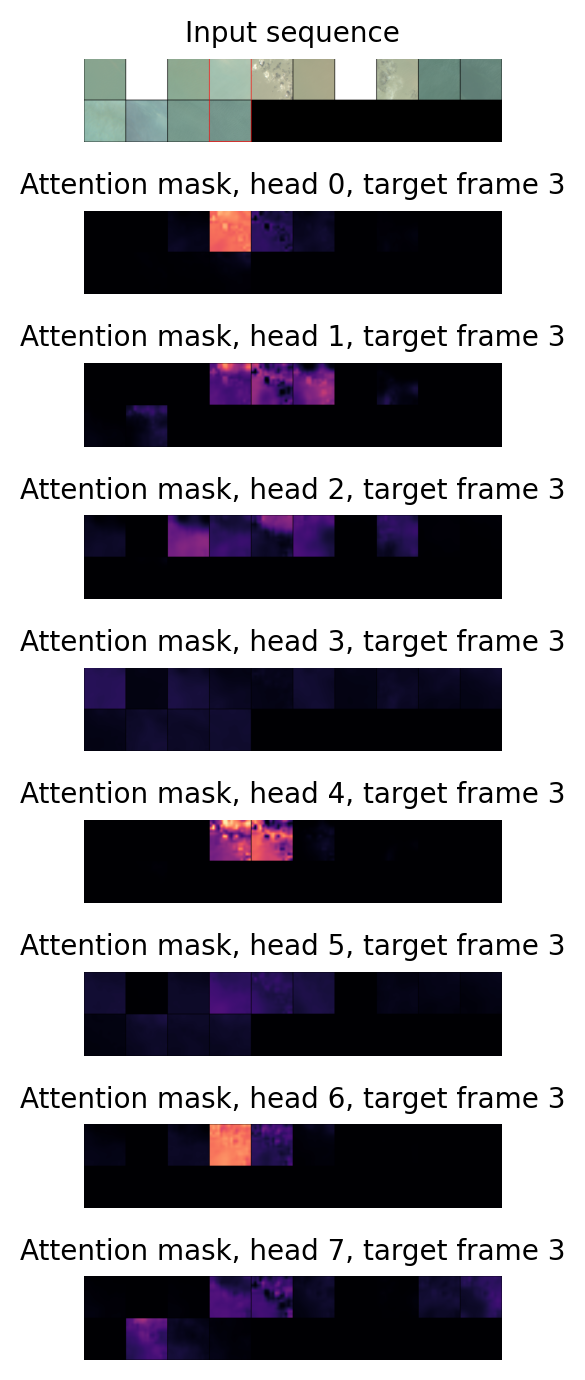

In [9]:
from src.eval_tools import visualize_att_for_target_t_across_heads

# Visualiser les masques de toutes les têtes d'attention pour une date cible
T_TARGET = 3  # Indice de la date cible à visualiser

fig_att = visualize_att_for_target_t_across_heads(
    seq=inputs, att=att,
    t_target=T_TARGET,
    batch=0,
    indices_rgb=idx_rgb,
    brightness_factor=3.0,
)
plt.show()

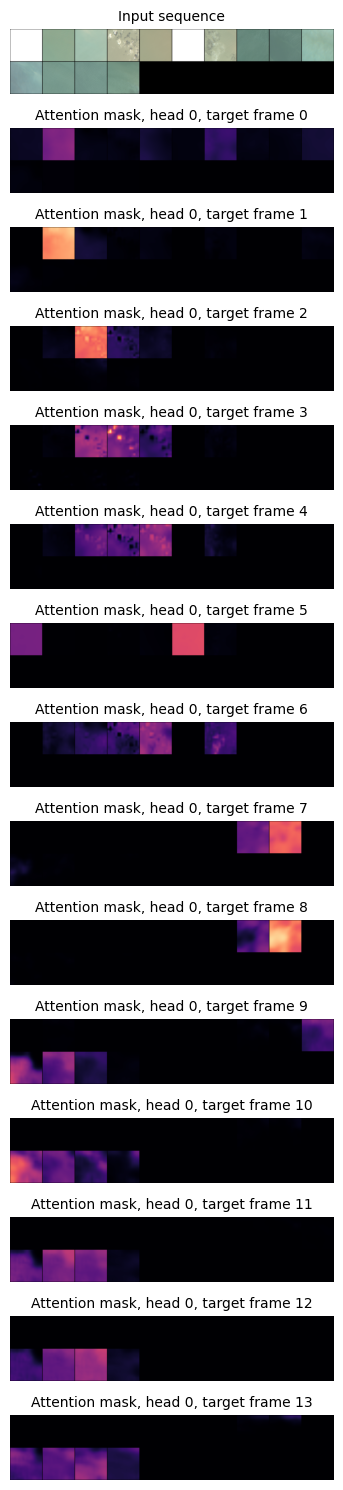

In [ ]:
from src.eval_tools import visualize_att_for_one_head_across_time

# Visualiser une tête d'attention donnée pour toutes les dates
HEAD = 0  # Indice de la tête d'attention

fig_att_head = visualize_att_for_one_head_across_time(
    seq=inputs, att=att,
    head=HEAD,
    batch=0,
    indices_rgb=idx_rgb,
    brightness_factor=3.0,
)
plt.show()

## 7. Calcul des métriques

Métriques de reconstruction calculées sur les pixels masqués et observés :
MAE, RMSE, PSNR, SSIM, SAM.

In [ ]:
from src.metrics.cloud_removal import CloudRemovalMetrics

compute_metrics = CloudRemovalMetrics(
    metrics=["mae", "rmse", "psnr", "ssim", "sam"],
    eval_occluded_observed=True,
)

# Calcul des métriques pour le premier échantillon du batch
# Signature : (target, masks, predicted, cloud_masks)
# cloud_mask est le masque spatial (B, T, 1, H, W), pas mask_valid qui est par timestep (B, T)
metrics = compute_metrics(
    target[0:1],
    masks[0:1],
    y_pred[0:1],
    cloud_mask[0:1] if cloud_mask is not None else None,
)

print("=== Métriques de reconstruction ===")
for name, value in metrics.items():
    if isinstance(value, (float, int)):
        print(f"  {name:30s} : {value:.4f}")
    elif hasattr(value, 'item'):
        print(f"  {name:30s} : {value.item():.4f}")

---

**Pour une évaluation complète** sur tout le jeu de test :

```bash
python run_eval.py configs/config_run_eval.yaml utilise
```

**Pour l'inférence à la tuile** (production de GeoTIFF) :

```bash
python run_inference.py configs/config_run_inference.yaml utilise
```

Voir le README pour les détails sur les modes de masquage et de fusion temporelle.